# Evaluate — DDPG A1 & A2, TD3 A1 & A2 on Juan's 4 days

Loads the four CURRENT best policies (`policies/*_best.pt`, trained in the tuned
stability-safe gain box `GAIN_LOW=[-30,-4.0,-0.4]`) and evaluates them on the four
newest Juan days: metrics table (MAE / RMSE / peak overshoot / undershoot) vs the
expert PI, one tracking chart per day (all four policies + expert), and the applied
flow. Charts are saved under `charts/evaluate/`. Evaluation only — no training.


In [7]:
# ── Setup: shared library (../main_script) + this folder's config ────────────
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch
sys.path.insert(0, os.getcwd())                                            # for: import config
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), os.pardir)))  # reach ../main_script
from main_script import *
import config as cfg
from config import *
configure(cfg)

# TUNED gain box — must match the per-notebook override of the 4 approach notebooks
cfg.GAIN_LOW  = np.array([-30.0, -4.0, -0.40], dtype=np.float32)
cfg.GAIN_HIGH = np.array([-0.05, -0.0001, 0.10], dtype=np.float32)

POLICIES = {
   'DDPG-A1': 'ddpg_online_ac_approach1_best.pt',
   'DDPG-A2': 'ddpg_online_ac_approach2_best.pt',
   'TD3-A1':  'td3_online_ac_approach1_best.pt',
   'TD3-A2':  'td3_online_ac_approach2_best.pt',
}

#POLICIES = {
#   'DDPG-A1': os.path.join('old_box', 'ddpg_online_ac_approach1_best_oldbox.pt'),
#    'DDPG-A2': os.path.join('old_box', 'ddpg_online_ac_approach2_best_oldbox.pt'),
#    'TD3-A1':  os.path.join('old_box', 'td3_online_ac_approach1_best_oldbox.pt'),
#    'TD3-A2':  os.path.join('old_box', 'td3_online_ac_approach2_best_oldbox.pt'),
#}

COLORS = {'DDPG-A1': '#d62728', 'DDPG-A2': '#ff7f0e', 'TD3-A1': '#1f77b4', 'TD3-A2': '#9467bd'}
actors = {tag: load_actor_raw(os.path.join(SAVE_DIR, f)) for tag, f in POLICIES.items()}

EV_DIR = os.path.join(CHART_DIR, 'evaluate'); os.makedirs(EV_DIR, exist_ok=True)

def undershoot_metric(T, tref):
    """Worst dip below T_ref AFTER the first crossing (startup climb excluded)."""
    above = np.nonzero(T >= tref)[0]
    return float(np.max(tref - T[above[0]:])) if len(above) else float(np.max(tref - T))

print(f"loaded {len(actors)} policies | decode box LOW={list(cfg.GAIN_LOW)} HIGH={list(cfg.GAIN_HIGH)}")


[load] raw actor from ddpg_online_ac_approach1_best.pt
[load] raw actor from ddpg_online_ac_approach2_best.pt
[load] raw actor from td3_online_ac_approach1_best.pt
[load] raw actor from td3_online_ac_approach2_best.pt
loaded 4 policies | decode box LOW=[np.float32(-30.0), np.float32(-4.0), np.float32(-0.4)] HIGH=[np.float32(-0.05), np.float32(-1e-04), np.float32(0.1)]


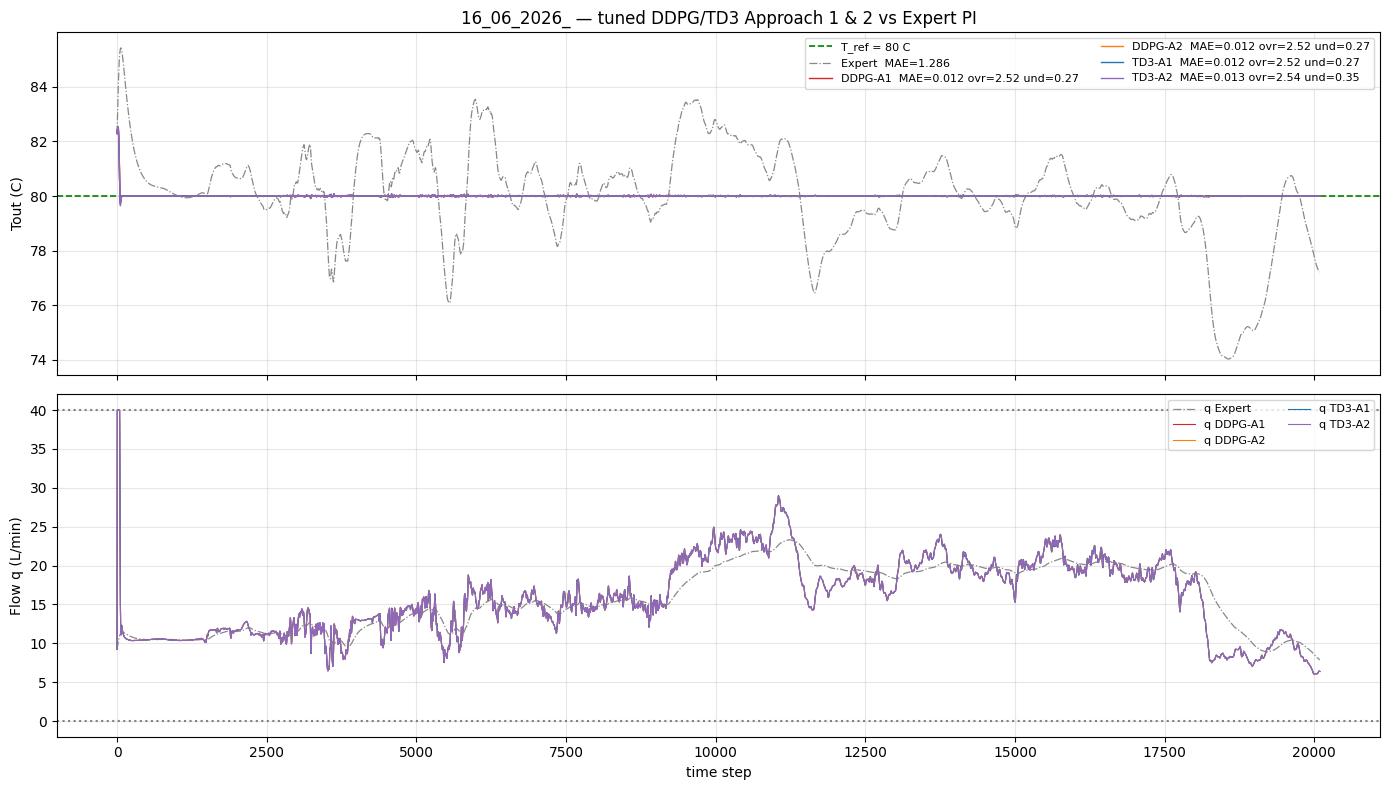

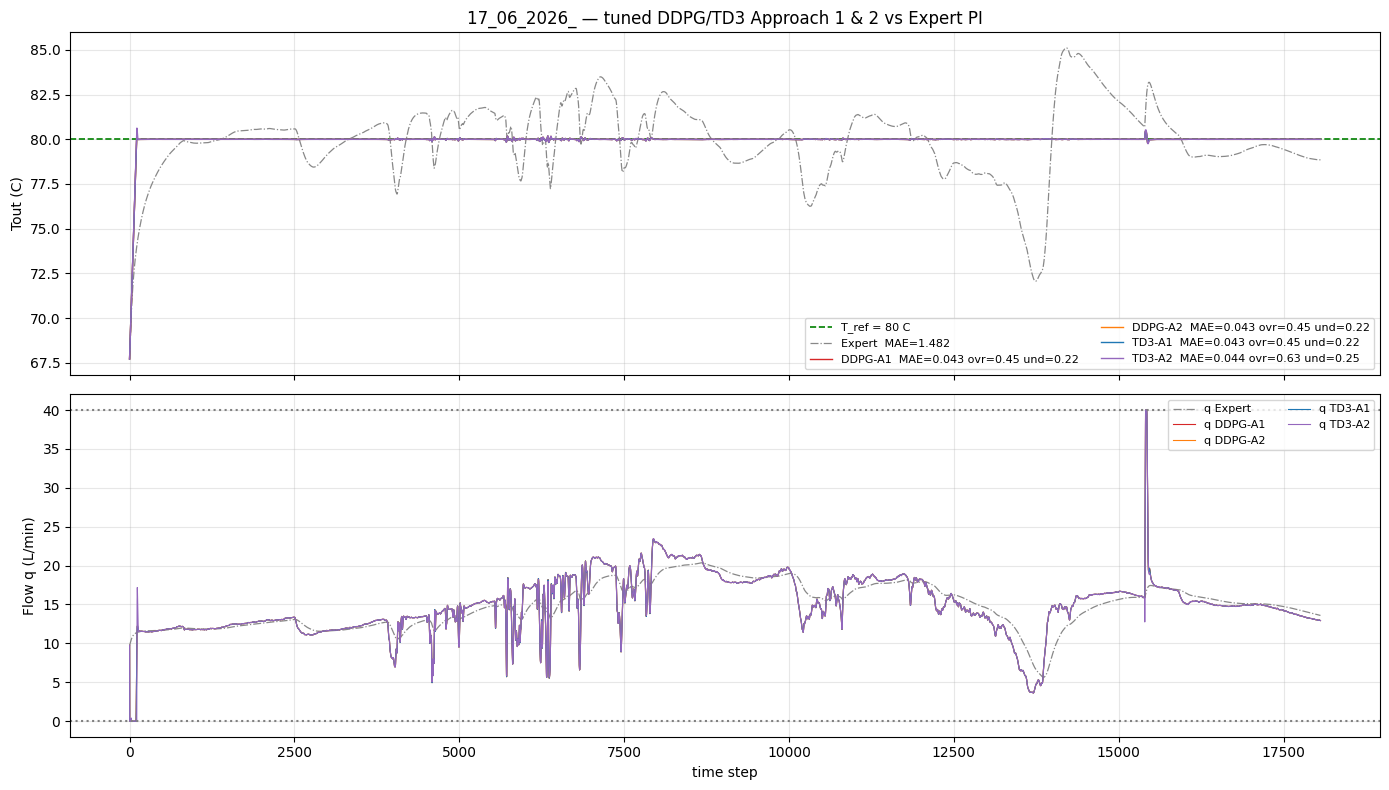

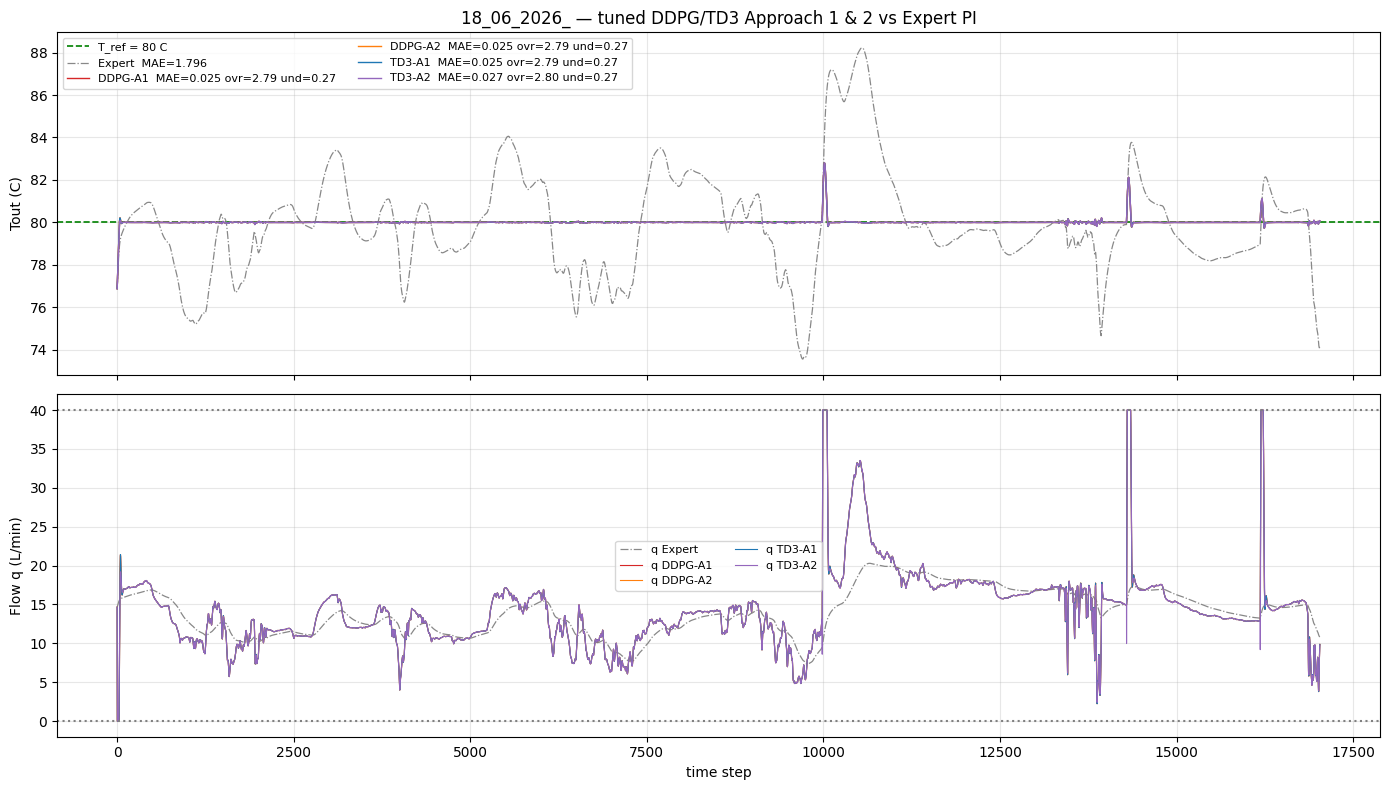

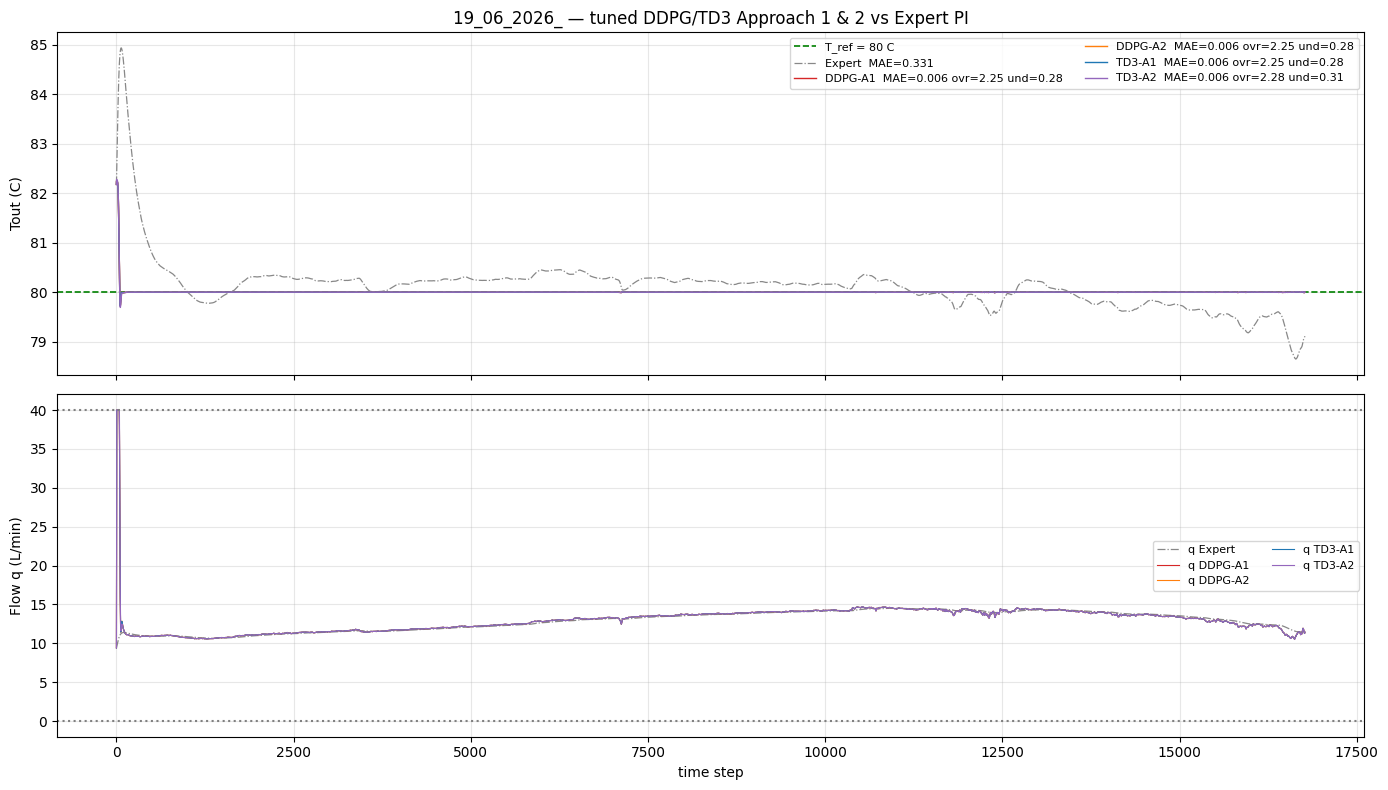

Per-day metrics:


,day,policy,MAE,RMSE,ovr,und
0,16_06_2026_,Expert,1.286,1.806,5.425,5.972
1,16_06_2026_,DDPG-A1,0.012,0.102,2.519,0.265
2,16_06_2026_,DDPG-A2,0.012,0.102,2.519,0.266
3,16_06_2026_,TD3-A1,0.012,0.102,2.519,0.266
4,16_06_2026_,TD3-A2,0.013,0.103,2.542,0.354
5,17_06_2026_,Expert,1.482,2.079,5.117,7.945
6,17_06_2026_,DDPG-A1,0.043,0.546,0.453,0.219
7,17_06_2026_,DDPG-A2,0.043,0.546,0.452,0.219
8,17_06_2026_,TD3-A1,0.043,0.546,0.452,0.219
9,17_06_2026_,TD3-A2,0.044,0.547,0.626,0.245


Summary over the 4 Juan days (mean MAE/RMSE; worst-day ovr/und):


,MAE,RMSE,ovr_worst,und_worst
policy,,,,
Expert,1.224,1.731,8.219,7.945
DDPG-A1,0.022,0.232,2.794,0.278
DDPG-A2,0.022,0.232,2.794,0.278
TD3-A1,0.022,0.232,2.794,0.278
TD3-A2,0.022,0.233,2.802,0.354


In [8]:
# ── Evaluate on Juan's 4 newest days: metrics table + one chart per day ───────
days = [load_dataset(f) for f in JUAN_FILES]

rows = []
for d in days:
    tr = dataset_tref(d['name'])
    Te, Qe = rollout_expert(d)
    m, rm = mae_rmse(Te, tr)
    rows.append(dict(day=d['name'][:11], policy='Expert', MAE=m, RMSE=rm,
                     ovr=peak_overshoot(Te, tr), und=undershoot_metric(Te, tr)))
    Ts = {}; Qs = {}
    for tag, actor in actors.items():
        T, Q, G = rollout_full(actor, d); Ts[tag] = T; Qs[tag] = Q
        m, rm = mae_rmse(T, tr)
        rows.append(dict(day=d['name'][:11], policy=tag, MAE=m, RMSE=rm,
                         ovr=peak_overshoot(T, tr), und=undershoot_metric(T, tr)))

    # chart: Tout (top, all policies + expert) and applied flow q (bottom)
    t = np.arange(len(Te))
    fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    ax[0].axhline(tr, ls='--', c='green', lw=1.2, label=f'T_ref = {tr:.0f} C')
    ax[0].plot(t, Te, c='#888888', ls='-.', lw=0.9, label=f'Expert  MAE={rows[-5]["MAE"]:.3f}')
    for tag in POLICIES:
        mt = [r for r in rows if r['day'] == d['name'][:11] and r['policy'] == tag][0]
        ax[0].plot(np.arange(len(Ts[tag])), Ts[tag], c=COLORS[tag], lw=1.0,
                   label=f"{tag}  MAE={mt['MAE']:.3f} ovr={mt['ovr']:.2f} und={mt['und']:.2f}")
    ax[0].set_ylabel('Tout (C)'); ax[0].grid(alpha=.3); ax[0].legend(fontsize=8, ncol=2)
    ax[0].set_title(f"{d['name'][:11]} — tuned DDPG/TD3 Approach 1 & 2 vs Expert PI")
    ax[1].plot(t, Qe, c='#888888', ls='-.', lw=0.9, label='q Expert')
    for tag in POLICIES:
        ax[1].plot(np.arange(len(Qs[tag])), Qs[tag], c=COLORS[tag], lw=0.8, label=f'q {tag}')
    ax[1].axhline(Q_MIN, color='gray', ls=':'); ax[1].axhline(Q_MAX, color='gray', ls=':')
    ax[1].set_ylabel('Flow q (L/min)'); ax[1].set_xlabel('time step'); ax[1].grid(alpha=.3)
    ax[1].legend(fontsize=8, ncol=2)
    fig.tight_layout()
    fig.savefig(os.path.join(EV_DIR, f"evaluate_day_{d['name'][:11]}.png"), dpi=140, bbox_inches='tight')
    plt.show(); plt.close(fig)

df = pd.DataFrame(rows)
print('Per-day metrics:')
display(df.round(3))
summ = df.groupby('policy').agg(MAE=('MAE', 'mean'), RMSE=('RMSE', 'mean'),
                                ovr_worst=('ovr', 'max'), und_worst=('und', 'max'))
summ = summ.loc[['Expert', 'DDPG-A1', 'DDPG-A2', 'TD3-A1', 'TD3-A2']]
print('Summary over the 4 Juan days (mean MAE/RMSE; worst-day ovr/und):')
display(summ.round(3))
df.to_csv(os.path.join(EV_DIR, 'evaluate_juan_days.csv'), index=False)
